In [ ]:
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import json
from IPython.display import display, Markdown

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))

# Load Gemini model
model = genai.GenerativeModel("gemini-pro")

print("Gemini model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini model loaded successfully.


# AI4SG Prototype — Water Quality Monitoring and Structured AI Reporting

In [ ]:
print("AI4SG water monitoring prototype completed successfully.")

AI4SG water monitoring prototype completed successfully.


In [ ]:
#Demonstration for AI4SG System: The Challenge of Unstructured Data
#When community members report issues like chemical smells near storm drains, the raw text can vary significantly.
#As demonstrated by running the extraction multiple times, the AI's free-form responses, while containing the correct information, lack a predictable format.
#This inconsistency poses a major challenge for automated systems within the City of San Jose Environmental Services Department. Without a standardized output,
#it would be impossible for your AI Processing pipeline to reliably parse, categorize, or act upon these reports.
#For example, a machine learning model designed to prioritize interventions based on 'urgency' or 'location' would fail if these fields are not consistently named and formatted across all incoming reports.
import google.generativeai as genai
from google.colab import userdata
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))

resident_message = (
    "There's a strong chemical smell near the storm drain on Elm Street, close to the creek. "
    "I'm worried about what's getting into the water."
)

def extract_unstructured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="Extract the location, issue type, contaminants, and urgency from this clean water and sanitation report."
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    return response.text

print("--- Resident message ---")
print(resident_message)
print("\n--- Unstructured extraction (run 3 times — notice the format changes) ---")
print("\nRun 1:")
print(extract_unstructured(resident_message))
print("\nRun 2:")
print(extract_unstructured(resident_message))
print("\nRun 3:")
print(extract_unstructured(resident_message))

--- Resident message ---
There's a strong chemical smell near the storm drain on Elm Street, close to the creek. I'm worried about what's getting into the water.

--- Unstructured extraction (run 3 times — notice the format changes) ---

Run 1:
Here's the extracted information:

*   **Location:** Elm Street, near the storm drain, close to the creek.
*   **Issue Type:** Chemical spill/discharge, potential water contamination.
*   **Contaminants:** Unidentified chemicals (indicated by strong chemical smell).
*   **Urgency:** High (strong chemical smell near a water source indicates potential immediate environmental and health risk).

Run 2:
Here's the breakdown of the report:

*   **Location:** Elm Street (near the storm drain, close to the creek)
*   **Issue Type:** Suspected chemical discharge/pollution
*   **Contaminants:** Unidentified chemicals (indicated by strong chemical smell)
*   **Urgency:** High (due to strong smell, proximity to a creek/water body, and unknown nature of the 

In [ ]:
# The schema — the form the AI must fill in exactly for Clean Water and Sanitation reports.
#Basically, these fields like location, issue type, contaminants observed, urgency, affected entities, department,
#and resident language are designed specifically for reporting water and sanitation issues in San Jose.
#By clearly defining what kind of information goes into each field, like using text or lists and setting urgency levels, we’re helping the AI understand exactly what to look for and extract.
#This makes the system much more organized because the AI can break down each report into structured, detailed data instead of just messy descriptions.
#That data can then be easily used in databases, risk analysis, and to send the right teams out to respond.
#For example, separating “issue type” from “contaminants observed” is important. One tells us the general problem, like a sewage leak, while the other tells us the specific substances involved,
#like bacteria or chemicals. That level of detail helps the city respond more accurately and efficiently, especially for complicated issues like pollution from encampments or problems caused by old infrastructure.

schema_prompt = """
Extract information from this resident report regarding clean water and sanitation issues.
Return ONLY valid JSON with exactly these seven fields:
{
  "location": string (the specific location of the issue, e.g., creek name, street address near a storm drain, water pipe location),
  "issue_type": string (the general type of problem, e.g., "illegal dumping", "water contamination", "sewage overflow", "storm drain blockage", "pipe leak", "aging infrastructure"),
  "contaminants_observed": array of strings (specific types of contaminants if observed, e.g., "biowaste", "trash", "used needles", "chemicals", "sediment"),
  "urgency": "LOW" or "MEDIUM" or "HIGH" or "CRITICAL",
  "affected_entities": array of strings (who or what is affected, e.g., "residents", "wildlife", "creek", "bay", "public health"),
  "department": string (which San Jose city department should respond: e.g. "City of San Jose Environmental Services Department", "Public Works", "Water Department", "Health Department", "Code Enforcement"),
  "resident_language": string (language the resident wrote in, e.g. "English", "Spanish", "Vietnamese")
}
Urgency guide: LOW = minor aesthetic issue, MEDIUM = moderate impact, requires attention; HIGH = significant environmental or health concern, prompt action needed; CRITICAL = immediate severe health risk or environmental disaster, emergency response required.
No explanation. No markdown. JSON only.
"""

print("New schema defined for Clean Water and Sanitation reports. The AI must return exactly these seven fields:")
for field in ["location", "issue_type", "contaminants_observed", "urgency", "affected_entities", "department", "resident_language"]:
    print(f"  - {field}")

New schema defined for Clean Water and Sanitation reports. The AI must return exactly these seven fields:
  - location
  - issue_type
  - contaminants_observed
  - urgency
  - affected_entities
  - department
  - resident_language


In [ ]:
#In this system, we use a predefined schema as part of the AI’s instructions so that every response follows the same structured JSON format.
#This guarantees consistency and makes the data predictable and easy to use.
#For example, no matter how a resident describes an issue such as reporting a chemical smell near a storm drain, the AI will always return standardized fields like "location", "issue_type", and "urgency".
#This consistency is critical because it allows the system to automatically process and act on the data without needing manual interpretation. It enables:
#Automated database entry into systems like 311 or custom water quality platforms Reliable machine learning input using clean
#and structured data Efficient dispatching by identifying the correct department (e.g., Environmental Services) Reduced human error and faster response times
#Overall, structured, machine-readable output transforms raw resident complaints into actionable insights for the City of San Jose.

import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))

def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)  # stays under free tier rate limit
    raw = response.text.strip()
    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

print("--- Resident message ---")
print(resident_message)
print("\n--- Structured extraction (run 3 times — format is identical each time) ---")

for i in range(1, 4):
    print(f"\nRun {i}:")
    result = extract_structured(resident_message)
    print(json.dumps(result, indent=2, ensure_ascii=False))

--- Resident message ---
There's a strong chemical smell near the storm drain on Elm Street, close to the creek. I'm worried about what's getting into the water.

--- Structured extraction (run 3 times — format is identical each time) ---

Run 1:
{
  "location": "storm drain on Elm Street, close to the creek",
  "issue_type": "water contamination",
  "contaminants_observed": [
    "chemicals"
  ],
  "urgency": "HIGH",
  "affected_entities": [
    "creek",
    "public health"
  ],
  "department": "City of San Jose Environmental Services Department",
  "resident_language": "English"
}

Run 2:
{
  "location": "storm drain on Elm Street, close to the creek",
  "issue_type": "water contamination",
  "contaminants_observed": [
    "chemicals"
  ],
  "urgency": "HIGH",
  "affected_entities": [
    "creek",
    "public health"
  ],
  "department": "City of San Jose Environmental Services Department",
  "resident_language": "English"
}

Run 3:
{
  "location": "storm drain on Elm Street, near th

In [ ]:
#This demonstration shows how the AI system performs across a variety of real-world water quality scenarios, including pipe leaks, biowaste dumping near creeks, cloudy tap water,
#and storm drain blockages even when reports are submitted in different languages like Spanish.
#The results highlight the system’s ability to:
#Accurately classify issue types and contaminants: The AI can identify specific problems such as "pipe leak" or "illegal dumping," along with contaminants like "biowaste" or "chemicals."
#This allows for more targeted and effective responses. Determine the appropriate department: Reports are correctly routed to departments such as the Water Department, Environmental Services,
#or Public Works, ensuring faster and more efficient handling. Identify affected entities: The system recognizes who or what is impacted, including residents, wildlife, or water sources like creeks.
#This helps assess severity and prioritize response. Detect resident language: The AI can identify whether a report is in English or Spanish,
#enabling city agencies to respond in the resident’s preferred language an important feature for serving San Jose’s diverse community.
#Overall, this demonstrates the system’s flexibility and reliability in handling a wide range of complaints while maintaining structured, actionable outputs.

test_messages = [
    {
        "label": "Pipe Leak",
        "message": "The water main on Maple Avenue has been leaking for days, causing a huge puddle and wasting a lot of water."
    },
    {
        "label": "Creek Dumping (Biowaste)",
        "message": "I saw a homeless encampment behind the Safeway on Capitol Ave. There's trash and what looks like biowaste near the creek, I'm worried about safety for my kids."
    },
    {
        "label": "Water Contamination (Cloudy Tap Water)",
        "message": "My tap water looks cloudy and tastes metallic this morning. Is it safe to drink? I live on 456 Pine Street."
    },
    {
        "label": "Storm Drain Blockage (Spanish)",
        "message": "La alcantarilla en la calle Oak y la avenida King está completamente bloqueada con basura después de la lluvia. El agua no está drenando y se está desbordando."
    }
]

for item in test_messages:
    print(f"=== {item['label']} ===")
    print(f"Input: {item['message']}")
    result = extract_structured(item["message"])
    print("Output:")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    print()

=== Pipe Leak ===
Input: The water main on Maple Avenue has been leaking for days, causing a huge puddle and wasting a lot of water.
Output:
{
  "location": "Maple Avenue",
  "issue_type": "pipe leak",
  "contaminants_observed": [],
  "urgency": "HIGH",
  "affected_entities": [
    "residents",
    "public infrastructure"
  ],
  "department": "Water Department",
  "resident_language": "English"
}

=== Creek Dumping (Biowaste) ===
Input: I saw a homeless encampment behind the Safeway on Capitol Ave. There's trash and what looks like biowaste near the creek, I'm worried about safety for my kids.
Output:
{
  "location": "Creek behind Safeway on Capitol Ave",
  "issue_type": "illegal dumping",
  "contaminants_observed": [
    "trash",
    "biowaste"
  ],
  "urgency": "HIGH",
  "affected_entities": [
    "residents",
    "creek",
    "public health"
  ],
  "department": "City of San Jose Environmental Services Department",
  "resident_language": "English"
}

=== Water Contamination (Cloudy 

In [ ]:
!pip install -q google-generativeai Pillow

In [ ]:
import google.generativeai as genai
from google.colab import userdata, files
import json
import time
from PIL import Image as PILImage

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

Gemini initialized successfully.


Saving download.png to download.png
Uploaded: download.png
Image size: 288x175 pixels


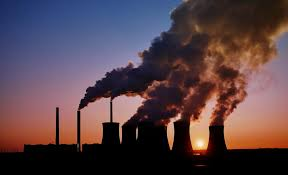

In [ ]:
# Upload an image file from the user's computer, open it using PIL,
# print the file name and image dimensions, and display the image
# inside the notebook for AI image analysis.

uploaded = files.upload()

image_filename = list(uploaded.keys())[0]

img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

In [ ]:
# This code cell creates a reusable function that analyzes uploaded images
# using the Gemini AI model. The function takes an image file and a text
# question as input, sends both to Gemini for image recognition, and returns
# the AI-generated response along with usage metadata. The function is later
# used to identify environmental hazards such as contaminated water, trash
# buildup, flooding, or infrastructure damage from uploaded community images.

def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


In [ ]:
# This code cell asks Gemini AI a series of civic and environmental
# analysis questions about the uploaded image.
# The questions focus on:
#   - identifying the environmental problem,
#   - explaining community and public health impacts,
#   - rating the urgency level,
#   - recommending which city department should respond.

# The loop sends each question and the uploaded image to the
# analyze_image() function, stores the AI responses in a dictionary,
# tracks the total number of tokens used, and prints the results.
# This demonstrates how AI can support the City of San Jose by
# automatically analyzing environmental hazards reported by residents.

civic_questions = [
    ("PROBLEM",  "Describe the civic or environmental problem visible in this image. Be specific about what you see."),
    ("IMPACT",   "What are the public health, safety, or community impacts of what is shown in this image?"),
    ("URGENCY",  "Rate the urgency of this situation as LOW, MEDIUM, or HIGH. Explain your rating in 2–3 sentences."),
    ("ACTION",   "Which specific city department or service should respond to this? What action should they take?")
]

civic_results = {"answers": {}, "total_tokens": 0}

for label, question in civic_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- PROBLEM ---
The image clearly depicts a large industrial facility, most likely a thermal power plant, silhouetted against a dramatic sunset or sunrise. The most visible and significant civic and environmental problem evident is **air pollution** and its consequences.

Here's a specific breakdown of what is seen and the problems it represents:

1.  **Multiple Tall Smokestacks Emitting Dark Plumes:** On the left side of the image, several tall, slender stacks are spewing dense, dark plumes of smoke and exhaust high into the atmosphere.
    *   **Environmental Problem:** The dark coloration indicates the release of **particulate matter** (soot, ash, fine dust) and various harmful **gases** resulting from the combustion of fossil fuels (like coal, oil, or natural gas). These emissions are a major contributor to:
        *   **Air quality degradation:** Causing smog and reduced visibility.
        *   **Greenhouse gas emissions:** Primarily carbon dioxide (CO2), which drives climate cha

In [ ]:
# This code cell allows the user to ask their own custom question
# about the uploaded environmental image. The question is sent
# together with the image to the analyze_image() function, which
# uses Gemini AI to generate an image-based response. The AI answer
# and the number of tokens used are then displayed. This demonstrates
# interactive AI image analysis where community members or city staff
# can investigate specific environmental concerns shown in the image.

custom_question = input("\nAsk your own question about the image: ")
custom_result, custom_usage = analyze_image(image_filename, custom_question)

print("\n--- Response ---")
print(custom_result)
print(f"\nTokens used: {custom_usage.total_token_count}")


Ask your own question about the image: What is the level of danger

--- Response ---
The image depicts what appears to be a **fossil fuel power plant**, likely a coal-fired plant, given the large cooling towers and multiple smokestacks emitting significant plumes.

The level of danger associated with such a facility is **significant**, primarily in terms of **environmental impact** and **long-term human health risks**, rather than immediate, acute danger to an observer from afar (unless there's an active catastrophic event, which isn't suggested by the static image).

Here's a breakdown of the dangers:

1.  **Air Pollution:**
    *   **Greenhouse Gases:** Large amounts of carbon dioxide (CO2) are emitted, contributing to climate change and global warming.
    *   **Particulate Matter (PM2.5, PM10):** Fine particles that can penetrate deep into the lungs, causing respiratory illnesses (asthma, bronchitis, emphysema), cardiovascular problems, and premature death.
    *   **Sulfur Dioxid

In [ ]:
# This code cell demonstrates a failure in the AI system.
# The prompt only tells Gemini to "Extract water issue info"
# without enforcing a structured JSON schema.

# As a result, the AI may return free-form natural language
# instead of valid JSON. Because json.loads() expects properly
# formatted JSON data, the code can fail with a parsing error.

# This is an important limitation because automated city systems
# require predictable machine-readable outputs to reliably process
# environmental reports. The failure demonstrates why
# schema-constrained prompting is necessary for consistent and
# reliable AI workflows.

user_report = "There is dirty water, trash, and a bad smell near a creek on Elm Street."

response = genai.GenerativeModel(
    model_name="gemini-2.5-flash",
    system_instruction="Extract water issue info."
).generate_content(user_report)

result = json.loads(response.text)

print(result)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)